In [11]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Generate three separate logistic function plots with consistent LaTeX-style axis labels

import numpy as np
import matplotlib.pyplot as plt

# Linear predictor range
x = np.linspace(-6, 6, 400)

betas = [0.5, 1.0, 2.0]

for beta in betas:
    p = 1 / (1 + np.exp(-beta * x))
    
    plt.figure()
    plt.plot(x, p)
    plt.xlabel(r"Linear predictor $\eta_i = X_i^\top \beta$")
    plt.ylabel(r"Predicted probability $p_i$")
    plt.title(f"Logistic Function ($\\beta$ = {beta})")
    plt.ylim(0, 1)
    plt.xlim(-6, 6)
    filename = f"logistic_beta_{beta}.png"
    plt.close()

print("Updated plots saved with consistent LaTeX-style axis labels.")



Updated plots saved with consistent LaTeX-style axis labels.


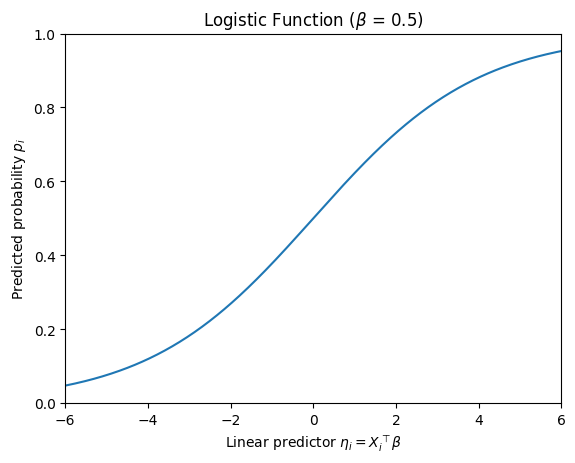

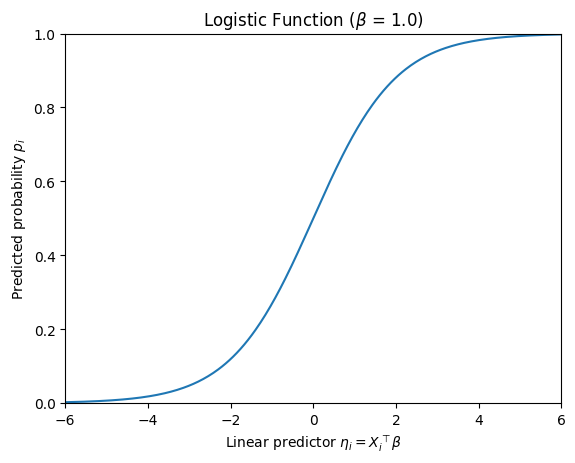

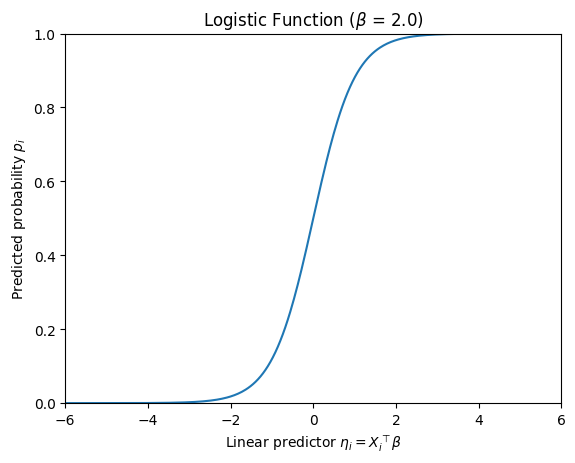

In [13]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-6, 6, 400)
betas = [0.5, 1.0, 2.0]

for beta in betas:
    p = 1 / (1 + np.exp(-beta * x))
    
    plt.figure()
    plt.plot(x, p)
    plt.xlabel(r"Linear predictor $\eta_i = X_i^\top \beta$")
    plt.ylabel(r"Predicted probability $p_i$")
    plt.title(f"Logistic Function ($\\beta$ = {beta})")
    plt.ylim(0, 1)
    plt.xlim(-6, 6)
    plt.show()

    filename = f"logistic_beta_{beta}_uniform_axes.png"
    save_path = "/Users/arttusokka/Documents/AThesis/Prediciting-ATP-matches-outcome/Kandinkuvaajat/"



In [14]:
#ELO GRAPHS FOR THE BIG 3.
df_clean["year"] = df_clean["tourney_date"].dt.year

top_players = ["Rafael Nadal", "Novak Djokovic", "Roger Federer"]

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(10,6))

for player in top_players:
    
    # Hae pelaajan ottelut
    player_rows = df_clean[
        (df_clean["player1_name"] == player) |
        (df_clean["player2_name"] == player)
    ].copy()
    
    # Valitse oikea pre-match ELO
    player_rows["elo"] = player_rows.apply(
        lambda row: row["elo_p1_pre"] 
        if row["player1_name"] == player 
        else row["elo_p2_pre"],
        axis=1
    )
    
    # Vuosi-keskiarvo
    yearly_mean = (
        player_rows
        .groupby("year")["elo"]
        .mean()
    )
    
    plt.plot(
        yearly_mean.index,
        yearly_mean.values,
        linewidth=2,
        label=player
    )

plt.title("Average Annual Pre-Match ELO Rating (2000–2019)")
plt.xlabel("Year")
plt.ylabel("Average ELO Rating")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'df_clean' is not defined

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Varmista datetime
df_clean["tourney_date"] = pd.to_datetime(
    df_clean["tourney_date"], format="%Y%m%d"
)

# Luo year-muuttuja
df_clean["year"] = df_clean["tourney_date"].dt.year

top_players = ["Rafael Nadal", "Novak Djokovic", "Roger Federer"]
surfaces = ["Clay", "Hard", "Grass"]  # varmista että nimet vastaavat datasettiäsi

plt.style.use("seaborn-v0_8-whitegrid")

for surface in surfaces:
    
    plt.figure(figsize=(10, 6))
    
    for player in top_players:
        
        player_rows = df_clean[
            (
                (df_clean["player1_name"] == player) |
                (df_clean["player2_name"] == player)
            )
            & (df_clean["surface"] == surface)
        ].copy()
        
        # Valitse oikea surface-elo
        player_rows["elo_surface"] = player_rows.apply(
            lambda row: row["elo_p1_pre_surface"]
            if row["player1_name"] == player
            else row["elo_p2_pre_surface"],
            axis=1
        )
        
        yearly_mean = (
            player_rows
            .groupby("year")["elo_surface"]
            .mean()
            .sort_index()
        )
        
        plt.plot(
            yearly_mean.index,
            yearly_mean.values,
            linewidth=2,
            label=player
        )
    
    plt.title(f"Average Annual Surface-Specific ELO ({surface})")
    plt.xlabel("Year")
    plt.ylabel("Average Pre-Match Surface ELO")
    
    # Pakota vuodet 2000–2019 kokonaislukuina
    plt.xticks(range(2000, 2020))
    plt.xlim(2000, 2019)
    
    plt.legend()
    plt.tight_layout()
    plt.show()


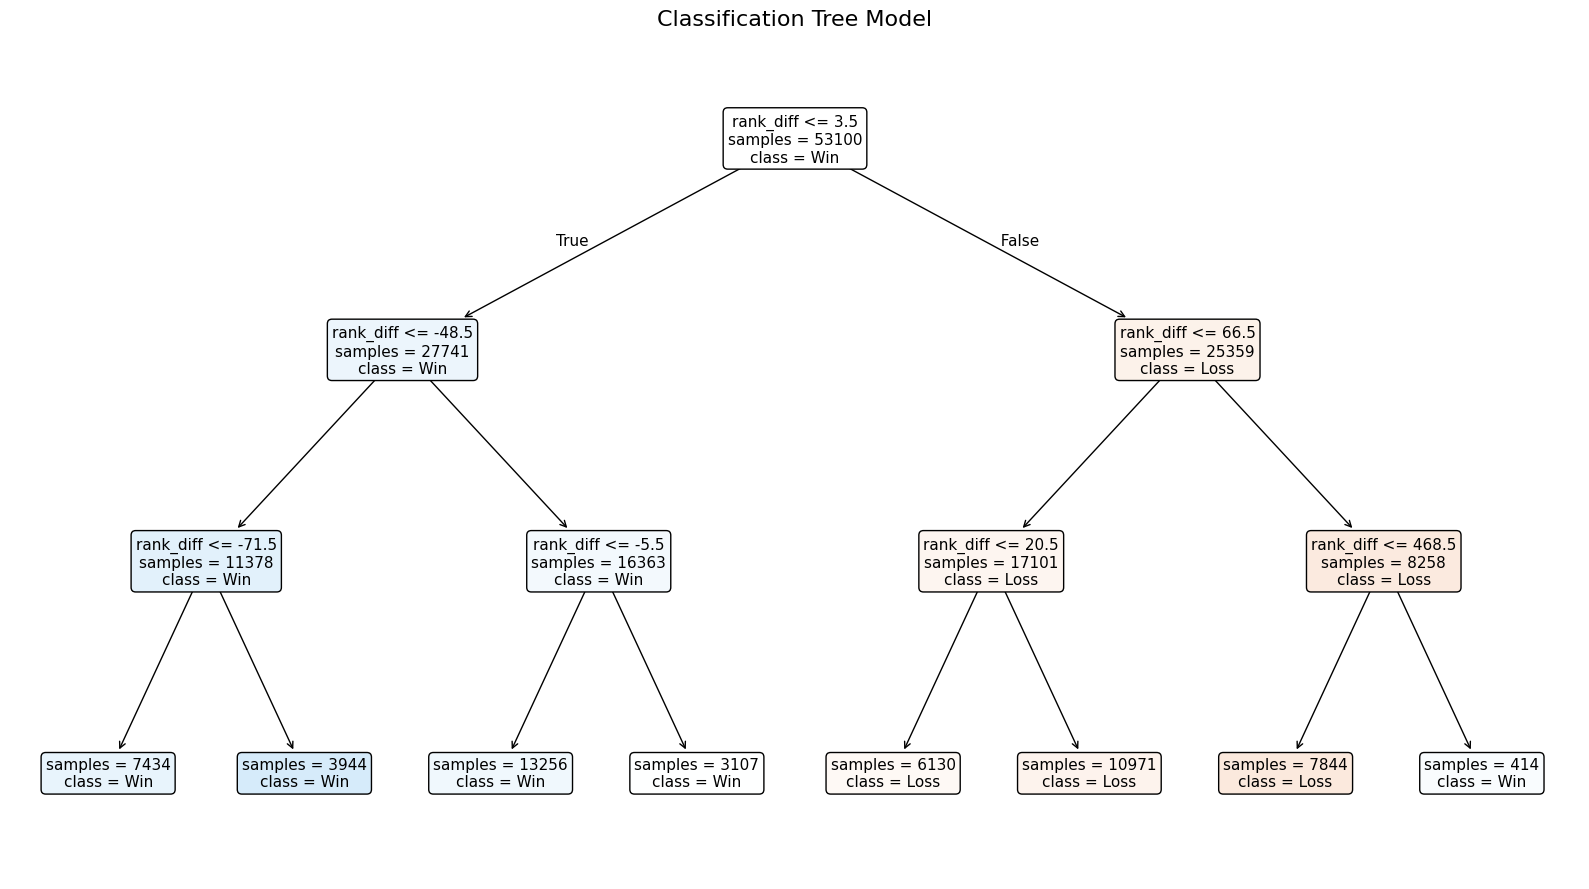

In [ ]:
# Piirretään puu normaalisti
fig, ax = plt.subplots(figsize=(16, 9))

tree_plot = plot_tree(
    tree_vis,
    feature_names=features,
    class_names=["Loss", "Win"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False,
    precision=2,
    fontsize=11,
)

# Poistetaan value-rivi jokaisesta laatikosta
for text in ax.texts:
    label = text.get_text()
    lines = label.split("\n")
    
    # Poistetaan rivit, jotka alkavat 'value'
    lines = [line for line in lines if not line.strip().startswith("value")]
    
    text.set_text("\n".join(lines))

plt.title("Classification Tree Model", fontsize=16)
plt.tight_layout()
plt.show()

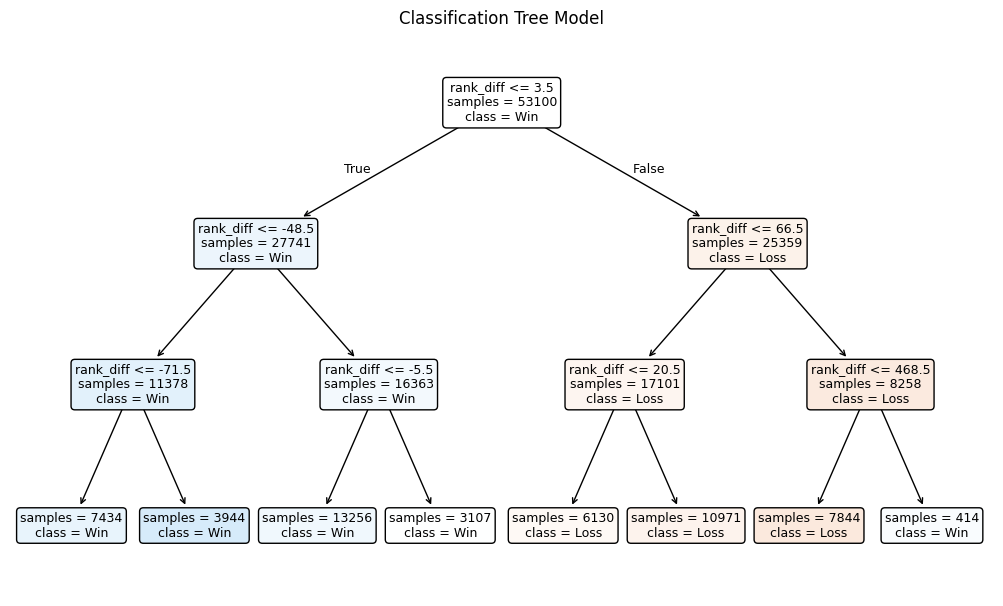

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))  # pienempi koko

tree_plot = plot_tree(
    tree_vis,
    feature_names=features,
    class_names=["Loss", "Win"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=False,
    precision=2,
    fontsize=9   # pienempi fontti
)

# Poistetaan value-rivi
for text in ax.texts:
    label = text.get_text()
    lines = label.split("\n")
    lines = [line for line in lines if not line.strip().startswith("value")]
    text.set_text("\n".join(lines))

plt.title("Classification Tree Model", fontsize=12)

plt.tight_layout(pad=0.5)   # vähemmän marginaalia
plt.margins(0)              # poistaa ylimääräistä whitespacea
plt.savefig("classification_tree.pdf", bbox_inches="tight")

plt.show()

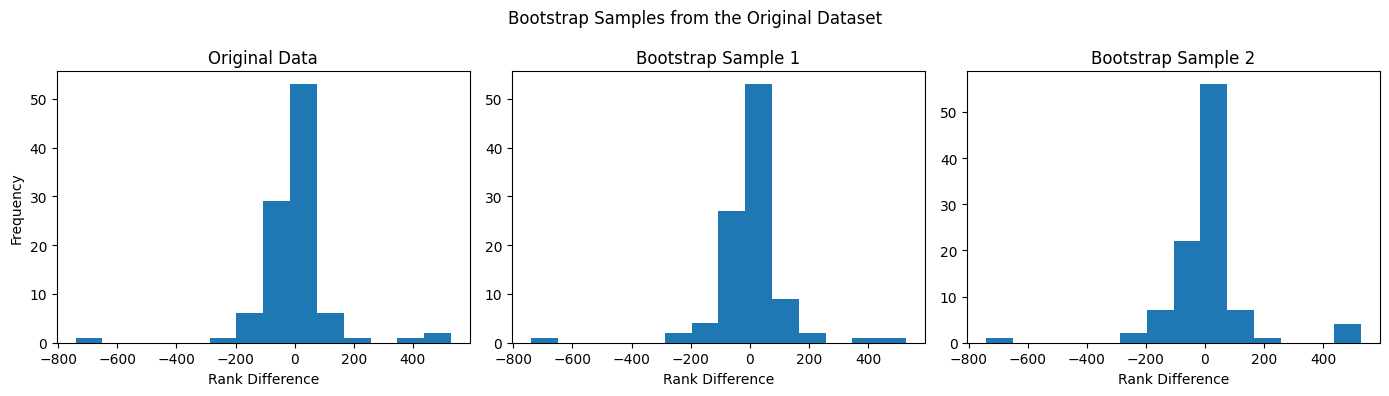

/Users/arttusokka/Documents/AThesis/Prediciting-ATP-matches-outcome/data_cleaning_preprocessing


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import os
np.random.seed(1)

# otetaan 100 havaintoa alkuperäisestä datasta
data = df["rank_diff"].dropna().sample(100, random_state=1).values

# bootstrap samplet samasta 100 havainnon joukosta
boot1 = np.random.choice(data, size=100, replace=True)
boot2 = np.random.choice(data, size=100, replace=True)

# yhteiset binit
bins = np.linspace(min(data), max(data), 15)

fig, axes = plt.subplots(1,3, figsize=(14,4))

axes[0].hist(data, bins=bins)
axes[0].set_title("Original Data")
axes[0].set_ylabel("Frequency")

axes[1].hist(boot1, bins=bins)
axes[1].set_title("Bootstrap Sample 1")

axes[2].hist(boot2, bins=bins)
axes[2].set_title("Bootstrap Sample 2")

for ax in axes:
    ax.set_xlabel("Rank Difference")

plt.suptitle("Bootstrap Samples from the Original Dataset")
plt.tight_layout()
plt.show()

fig.suptitle("Bootstrap Samples from the Original Dataset")

fig.tight_layout(rect=[0,0,1,0.95])
fig.savefig("bootstrap_samples.pdf", bbox_inches="tight")
print(os.getcwd())


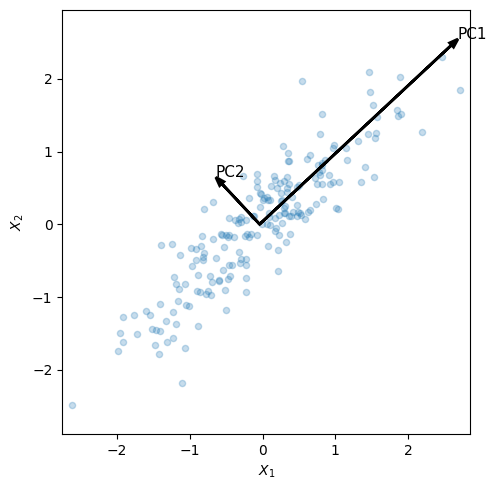

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Generate correlated data
np.random.seed(42)
x1 = np.random.normal(0, 1, 200)
x2 = 0.8 * x1 + np.random.normal(0, 0.4, 200)
X = np.column_stack((x1, x2))

# Fit PCA
pca = PCA(n_components=2)
pca.fit(X)

mean = X.mean(axis=0)
components = pca.components_
variance = pca.explained_variance_

# Plot
plt.figure(figsize=(5,5))

# datapoints
plt.scatter(X[:,0], X[:,1], alpha=0.25, s=20)

# PC arrows
for i in range(2):
    
    vector = components[i] * np.sqrt(variance[i]) * 3
    
    plt.arrow(
        mean[0], mean[1],
        vector[0], vector[1],
        head_width=0.08,
        length_includes_head=True,
        linewidth=2,
        color="black"
    )

# labels for PCs
v1 = components[0] * np.sqrt(variance[0]) * 3
v2 = components[1] * np.sqrt(variance[1]) * 3

plt.text(mean[0] + v1[0], mean[1] + v1[1], "PC1", fontsize=11)
plt.text(mean[0] + v2[0], mean[1] + v2[1], "PC2", fontsize=11)

#let's add 90 degree note between PC1 and PC2
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")

plt.axis("equal")
plt.grid(False)

plt.tight_layout()
plt.savefig("pca_visualization.pdf")
plt.show()

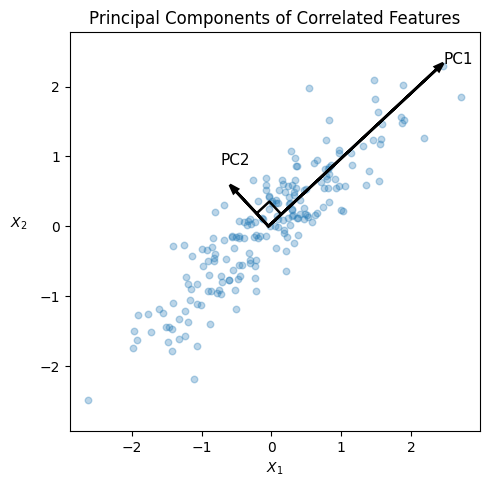

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Generate correlated data
np.random.seed(42)
x1 = np.random.normal(0, 1, 200)
x2 = 0.8 * x1 + np.random.normal(0, 0.4, 200)
X = np.column_stack((x1, x2))

# PCA
pca = PCA(n_components=2)
pca.fit(X)

mean = X.mean(axis=0)
components = pca.components_
variance = pca.explained_variance_

plt.figure(figsize=(5,5))

# Darker datapoints
plt.scatter(X[:,0], X[:,1], alpha=0.3, s=22)

vectors = []
for i in range(2):

    vector = components[i] * np.sqrt(variance[i]) * 2.75
    vectors.append(vector)

    plt.arrow(
        mean[0], mean[1],
        vector[0], vector[1],
        head_width=0.08,
        length_includes_head=True,
        linewidth=2,
        color="black"
    )

# Labels
plt.text(mean[0] + vectors[0][0], mean[1] + vectors[0][1], "PC1", fontsize=11)
plt.text(mean[0] + v2[0], mean[1] + v2[1] + 0.15, "PC2", fontsize=11)# Right-angle marker (square)
v1 = vectors[0] / np.linalg.norm(vectors[0])
v2 = vectors[1] / np.linalg.norm(vectors[1])

size = 0.25

p0 = mean
p1 = mean + v1 * size
p2 = p1 + v2 * size
p3 = mean + v2 * size

plt.plot(
    [p0[0], p1[0], p2[0], p3[0]],
    [p0[1], p1[1], p2[1], p3[1]],
    linewidth=1.8,
    color="black"
)

# Axes

plt.xlabel("$X_1$")
plt.ylabel("$X_2$", rotation=0, labelpad=15)
plt.axis("equal")
plt.grid(False)

plt.tight_layout(rect=[0,0,1,0.95])
plt.title("Principal Components of Correlated Features", fontsize=12)
plt.savefig("pca_visualization.pdf")
plt.show()

NameError: name 'df_clean' is not defined